# Prophet — comparaison de fenêtres d'entraînement glissantes (RTE)

Ce notebook explore une approche différente de `training/train_timeseries_models.ipynb` : au lieu
d'une fenêtre d'entraînement **expansive** (tout l'historique avant chaque cutoff) évaluée sur toute
l'année 2025, on compare ici des modèles Prophet entraînés sur des **fenêtres glissantes de durée
fixe** (3 ans, 1 an, 26 semaines, 12 semaines, 4 semaines — "3y" et "1y" implémentées pour
l'instant), évalués **uniquement** sur 2 fenêtres de 2 semaines (hiver et été 2025), avec un cutoff
quotidien à minuit UTC (réentraînement + prévision des 24h suivantes).

**Nouveautés par rapport au notebook précédent** :
- Dataset `data/training_dataset_2022_2025.csv` (année 2021 retirée).
- 4 régresseurs météo au lieu d'1 seul : `temperature_weighted_mean`, `temperature_min`,
  `temperature_max`, `temperature_std` (toujours la même limitation : valeurs réelles utilisées
  comme proxy de prévision météo, faute de prévisions archivées).
- Saisonnalités **adaptées à la durée de la fenêtre glissante** (ex: pas de saisonnalité annuelle
  si la fenêtre fait moins d'un an — Prophet ne peut pas estimer une saisonnalité qu'il n'a jamais
  vue en entier).
- Graphe à 2 courbes seulement (réel vs prédiction chaînée), pas de séparation par horizon.
- `ds` reste en UTC naïf, comme dans le notebook précédent (évite les doublons de timestamp au
  changement d'heure d'hiver — voir ce notebook pour le détail du raisonnement).

MLflow tourne dans une expérience **séparée** (`rte-consumption-forecast-sliding-window`) : le MAPE
calculé ici (sur seulement 4 semaines de test) n'est pas comparable au MAPE annuel des autres
notebooks, les mélanger dans la même expérience créerait une confusion.

**Conclusion** : pas encore rédigée dans ce notebook — viendra une fois tous les modèles comparés
(tableau récapitulatif MLflow).


## 1. Imports

In [ ]:
# Librairies de base
import logging

import numpy as np
import pandas as pd

# Coupe le message "Importing plotly failed" (loggé en niveau ERROR par Prophet) dans le processus
# principal du notebook — bruit sans conséquence, on n'utilise pas les graphes interactifs de
# Prophet (juste matplotlib). NB : ce message peut quand même réapparaître pendant les sections
# "Modèle ..." (une par worker joblib) — les cutoffs sont exécutés en parallèle dans des processus
# séparés (voir section 5), chacun réimportant `prophet` de son côté sans hériter de ce réglage.
# Solution complète testée mais non retenue : installer `plotly` (~68 Mo, jamais utilisé) pour que
# l'import interne de Prophet réussisse silencieusement partout. Accepté comme bruit cosmétique.
logging.getLogger("prophet.plot").setLevel(logging.CRITICAL)

# Prophet : modèle de série temporelle (tendance + saisonnalités + régresseurs + jours fériés)
from prophet import Prophet

# Parallélisation des cutoffs indépendants (fit + predict) sur tous les cœurs disponibles, avec
# une barre de progression (tqdm, déjà installé comme dépendance de Prophet)
from joblib import Parallel, delayed
from tqdm import tqdm

# Métriques, cohérentes avec les notebooks précédents (MAPE en %)
from sklearn.metrics import mean_absolute_percentage_error

# MLflow, backend local (base sqlite séparée de l'expérience des autres notebooks)
import mlflow

import matplotlib.pyplot as plt


## 2. Configuration

In [41]:
# Dataset sans l'année 2021 (chemin relatif au dossier training/)
DATA_PATH = "../data/training_dataset_2022_2025.csv"

# Mêmes fenêtres de test que le notebook précédent, pour rester comparable visuellement
PLOT_WINDOWS = {
    "hiver": (pd.Timestamp("2025-01-06T00:00:00"), pd.Timestamp("2025-01-20T00:00:00")),
    "été": (pd.Timestamp("2025-07-07T00:00:00"), pd.Timestamp("2025-07-21T00:00:00")),
}

# Espacement entre deux réentraînements pendant le test — variable ajustable (ex: pd.Timedelta(12, unit="h")
# ou pd.Timedelta(2, unit="D")) ; défaut = un réentraînement par jour, à minuit UTC. unit explicite
# (plutôt que days=1) : évite le DeprecationWarning numpy sur les Timedelta construits via un mot-clé
RETRAIN_INTERVAL = pd.Timedelta(1, unit="D")

# Régresseurs météo : toutes les statistiques horaires disponibles dans le dataset, pas seulement
# la moyenne pondérée utilisée dans le notebook précédent
REGRESSOR_COLUMNS = [
    "temperature_weighted_mean", "temperature_min", "temperature_max", "temperature_std",
]

# Une entrée par durée de fenêtre glissante à comparer. "3y" et "1y" sont implémentées ; les
# suivantes seront ajoutées en répétant le schéma de la section 6/6bis.
# yearly_seasonality désactivée dès que la fenêtre ne couvre pas au moins un an complet — Prophet
# ne peut pas estimer une saisonnalité annuelle fiable sans avoir vu au moins un cycle complet.
# Pour "1y" (cas limite, un seul cycle annuel vu) : gardée activée malgré tout, pour ne pas rendre
# ce modèle quasi équivalent à "26w" (qui n'a pas non plus de saisonnalité annuelle) — décision
# prise consciemment, à confronter aux résultats.
SLIDING_WINDOW_CONFIGS = {
    "3y": {
        "train_window": pd.DateOffset(years=3),
        "yearly_seasonality": True,
        "weekly_seasonality": True,
        "daily_seasonality": True,
    },
    "1y": {
        "train_window": pd.DateOffset(years=1),
        "yearly_seasonality": True,
        "weekly_seasonality": True,
        "daily_seasonality": True,
    },
    "26w": {
        "train_window": pd.DateOffset(weeks=26), 
        "yearly_seasonality": False, 
        "weekly_seasonality": True, 
        "daily_seasonality": True,
    },
    "12w": {
        "train_window": pd.DateOffset(weeks=12), 
        "yearly_seasonality": False, 
        "weekly_seasonality": True, 
        "daily_seasonality": True,
    },
    "4w":  {
        "train_window": pd.DateOffset(weeks=4),  
        "yearly_seasonality": False, 
        "weekly_seasonality": True, 
        "daily_seasonality": True,
    },
    # Variante de "4w" : au lieu d'une seule saisonnalité hebdomadaire Prophet standard, on la
    # remplace par 2 saisonnalités hebdo conditionnelles (weekday / weekend, condition_name porté
    # par les colonnes is_weekday/is_weekend de prophet_df) — permet des profils de consommation
    # différents en semaine vs le week-end plutôt qu'une seule courbe hebdo moyenne. Consommé par
    # _fit_and_predict_one_cutoff via le flag weekly_seasonality_split.
    "4w_split": {
        "train_window": pd.DateOffset(weeks=4),
        "yearly_seasonality": False,
        "weekly_seasonality": False,  # remplacée par les 2 saisonnalités conditionnelles ci-dessous
        "daily_seasonality": True,
        "weekly_seasonality_split": True,
    },
}

# Tracking MLflow en local (pas de serveur distant), expérience dédiée à cette comparaison
MLFLOW_TRACKING_URI = "sqlite:///../mlflow.db"
EXPERIMENT_NAME = "rte-consumption-forecast-sliding-window"

# Grille de recherche pour le fine-tuning des modèles "4w"/"4w_split" (section 7). Valeurs choisies
# autour de la config déjà validée en production (changepoint_prior_scale=0.35,
# seasonality_prior_scale=0.5, cf. RTE_predictions/ml/prophet/model_prophet.py) et des défauts
# Prophet (changepoint_prior_scale=0.05, seasonality_prior_scale=10.0), pour couvrir les deux
# régimes. Ajustable librement (grille plus grande = recherche plus longue).
CHANGEPOINT_PRIOR_SCALES = [0.05, 0.2, 0.35, 0.5]
SEASONALITY_PRIOR_SCALES = [0.5, 1.0, 5.0, 10.0]
SEASONALITY_MODES = ["additive", "multiplicative"]


## 3. Chargement des données brutes

In [22]:
hourly = pd.read_csv(DATA_PATH, parse_dates=["datetime_utc"]).set_index("datetime_utc").sort_index()

print(f"{len(hourly)} lignes, de {hourly.index.min()} à {hourly.index.max()}")


35064 lignes, de 2021-12-31 23:00:00+00:00 à 2025-12-31 22:00:00+00:00


## 4. Préparation du dataframe Prophet

Mêmes principes que le notebook précédent (`ds` en UTC naïf pour éviter les doublons de timestamp
au changement d'heure), avec 4 colonnes de régresseurs météo au lieu d'une seule.


In [33]:
prophet_df = pd.DataFrame({
    "ds": hourly.index.tz_localize(None),
    "y": hourly["consumption"].to_numpy(),
    "temperature_weighted_mean": hourly["temperature_weighted_mean"].to_numpy(),
    "temperature_min": hourly["temperature_min"].to_numpy(),
    "temperature_max": hourly["temperature_max"].to_numpy(),
    "temperature_std": hourly["temperature_std"].to_numpy(),
})

# Indicateurs jour de semaine / week-end (sur ds, donc en UTC — même convention que le reste du
# notebook), utilisés par les modèles à saisonnalité hebdomadaire conditionnelle (ex: "4w_split",
# section 6sexies) via Prophet.add_seasonality(condition_name=...). Colonnes inoffensives pour les
# modèles qui ne les utilisent pas (Prophet ignore les colonnes dont il n'a pas besoin).
prophet_df["is_weekday"] = prophet_df["ds"].dt.dayofweek < 5
prophet_df["is_weekend"] = ~prophet_df["is_weekday"]

prophet_df.head()


,ds,y,temperature_weighted_mean,temperature_min,temperature_max,temperature_std,is_weekday,is_weekend
0,2021-12-31 23:00:00,53089.5,8.46,4.0,12.4,1.89,True,False
1,2022-01-01 00:00:00,52049.0,9.43,3.9,15.7,2.26,False,True
2,2022-01-01 01:00:00,50369.5,8.35,2.7,15.9,2.56,False,True
3,2022-01-01 02:00:00,47676.5,8.26,2.3,15.4,2.62,False,True
4,2022-01-01 03:00:00,46050.0,7.97,3.2,15.5,2.55,False,True


## 5. Fonctions génériques

Ces fonctions sont écrites pour être réutilisées telles quelles par toutes les durées de fenêtre
glissante (`SLIDING_WINDOW_CONFIGS`).

- `_fit_and_predict_one_cutoff` : le travail d'**un seul cutoff** (fit + predict 24h), en fonction
  autonome (pas de closure sur les variables du notebook) pour pouvoir tourner dans un processus
  séparé.
- `run_sliding_window_evaluation` : pour une fenêtre de test donnée, répartit les cutoffs (espacés
  de `RETRAIN_INTERVAL`) sur tous les cœurs disponibles via `joblib` — chaque cutoff est indépendant
  des autres (fit sur sa propre tranche glissante de données), donc parallélisable sans risque. Si
  `RETRAIN_INTERVAL` < 24h, les prévisions de cutoffs successifs se chevauchent sur certaines
  heures : on garde alors la plus récente (celle du cutoff le plus proche) pour chaque heure réelle.
- `plot_actual_vs_prediction` : graphe à 2 courbes (réel vs prédiction chaînée), MAPE dans le titre.
- `run_sliding_window_model` : orchestre les trois fonctions ci-dessus pour un `model_label` donné
  (ex: `"3y"`) — run MLflow, les 2 fenêtres de test (hiver/été), les 2 graphes, le MAPE moyen. C'est
  cette fonction que chaque section "Modèle ..." appelle, pour éviter de répéter le même bloc
  d'entraînement à chaque nouvelle durée de fenêtre.


In [38]:
def _fit_and_predict_one_cutoff(cutoff, train_window, seasonality_config, prophet_df, regressor_columns):
    """Réentraîne Prophet sur la fenêtre glissante se terminant à `cutoff`, puis prédit les 24h
    suivantes. Fonction autonome (tous les paramètres passés explicitement, pas de closure) pour
    être exécutable dans un processus séparé par joblib."""
    train_slice = prophet_df[(prophet_df["ds"] >= cutoff - train_window) & (prophet_df["ds"] < cutoff)]

    model = Prophet(
        growth="linear",
        daily_seasonality=seasonality_config["daily_seasonality"],
        weekly_seasonality=seasonality_config["weekly_seasonality"],
        yearly_seasonality=seasonality_config["yearly_seasonality"],
        # .get(..., défaut Prophet) : absents pour les configs "3y"..."4w_split" (jamais tunées),
        # donc identiques au comportement Prophet par défaut tant qu'on ne passe pas par le
        # fine-tuning de la section 7, qui les surcharge explicitement.
        seasonality_mode=seasonality_config.get("seasonality_mode", "additive"),
        changepoint_prior_scale=seasonality_config.get("changepoint_prior_scale", 0.05),
        seasonality_prior_scale=seasonality_config.get("seasonality_prior_scale", 10.0),
    )

    # Saisonnalité hebdo conditionnelle (weekday/weekend) plutôt que la saisonnalité hebdo unique
    # de Prophet — voir "4w_split" dans SLIDING_WINDOW_CONFIGS. Nécessite que train_slice/future
    # contiennent les colonnes booléennes is_weekday/is_weekend (ajoutées une fois pour toutes à
    # prophet_df en section 4).
    if seasonality_config.get("weekly_seasonality_split"):
        model.add_seasonality(name="weekly_weekday", period=7, fourier_order=3, condition_name="is_weekday")
        model.add_seasonality(name="weekly_weekend", period=7, fourier_order=3, condition_name="is_weekend")

    model.add_country_holidays(country_name="FR")
    for col in regressor_columns:
        model.add_regressor(col)
    model.fit(train_slice)

    # pd.Timedelta(valeur, unit=...) plutôt que pd.Timedelta(hours=...) : évite le
    # DeprecationWarning numpy sur les Timedelta construits via un mot-clé
    future_ds = pd.date_range(cutoff + pd.Timedelta(1, unit="h"), periods=24, freq="h")
    # is_weekday/is_weekend toujours inclus dans le merge (même pour les modèles qui ne les
    # utilisent pas) : Prophet ignore les colonnes dont il n'a pas besoin, donc pas de branchement
    # conditionnel nécessaire ici.
    future = pd.DataFrame({"ds": future_ds}).merge(
        prophet_df[["ds"] + regressor_columns + ["is_weekday", "is_weekend"]], on="ds", how="left"
    )
    forecast = model.predict(future)
    return pd.DataFrame({"ds": future_ds, "yhat": forecast["yhat"].to_numpy(), "cutoff": cutoff})


def run_sliding_window_evaluation(window_start, window_end, train_window, seasonality_config,
                                   retrain_interval=None, n_jobs=-1, desc=None):
    """Pour une fenêtre de test (ex: les 2 semaines d'hiver), réentraîne Prophet à chaque cutoff
    (espacés de retrain_interval, en partant de window_start) sur les `train_window` dernières
    données glissantes, puis prédit les 24h suivantes. Les cutoffs sont indépendants les uns des
    autres : on les répartit sur tous les cœurs disponibles (n_jobs=-1) via joblib, au lieu de les
    traiter un par un séquentiellement.

    `desc` : libellé affiché devant la barre de progression (ex: "3y - hiver"), pour distinguer
    les différents appels (un par modèle x fenêtre) sans multiplier les lignes affichées — tqdm
    met à jour une seule ligne en continu (pourcentage, cutoffs traités, temps écoulé/restant).

    `retrain_interval=None` résolu vers RETRAIN_INTERVAL (section 2) à l'intérieur de la fonction
    plutôt qu'en valeur par défaut du paramètre — une valeur par défaut n'est évaluée qu'une seule
    fois, au moment où Python lit `def ...`, pas à chaque appel. Si cette cellule tourne avant la
    cellule de configuration (après un redémarrage du kernel, par exemple), ça évite un NameError
    (voir la même remarque, plus détaillée, sur tune_4w_hyperparameters en section 7)."""
    if retrain_interval is None:
        retrain_interval = RETRAIN_INTERVAL

    cutoffs = []
    cutoff = window_start
    while cutoff < window_end:
        cutoffs.append(cutoff)
        cutoff += retrain_interval

    # return_as="generator_unordered" : les résultats arrivent dès qu'un cutoff termine (peu importe
    # l'ordre, on trie de toute façon plus bas), ce qui permet à tqdm de progresser en temps réel
    # plutôt que d'attendre la fin de tous les cutoffs pour n'afficher qu'un seul saut à 100%.
    rows = list(tqdm(
        Parallel(n_jobs=n_jobs, return_as="generator_unordered")(
            delayed(_fit_and_predict_one_cutoff)(c, train_window, seasonality_config, prophet_df, REGRESSOR_COLUMNS)
            for c in cutoffs
        ),
        total=len(cutoffs),
        desc=desc or "Cutoffs",
    ))

    # Concatène tous les cutoffs, puis garde la prévision la plus fraîche par heure réelle (utile
    # seulement si retrain_interval < 24h et que les prévisions se chevauchent)
    result_df = pd.concat(rows, ignore_index=True).sort_values(["ds", "cutoff"])
    result_df = result_df.drop_duplicates("ds", keep="last")
    result_df = result_df.merge(prophet_df[["ds", "y"]], on="ds", how="left")
    return result_df[(result_df["ds"] >= window_start) & (result_df["ds"] < window_end)]


def plot_actual_vs_prediction(window_label, model_label, result_df):
    """Graphe à 2 courbes : consommation réelle vs prédiction chaînée (une prévision par cutoff,
    mises bout à bout). Retourne le MAPE affiché dans le titre."""
    mape = mean_absolute_percentage_error(result_df["y"], result_df["yhat"]) * 100

    plt.figure(figsize=(14, 5))
    plt.plot(result_df["ds"], result_df["y"], label="Consommation réelle", color="black", linewidth=2)
    plt.plot(
        result_df["ds"], result_df["yhat"], label=f"Prévision ({model_label})",
        color="tab:blue", linestyle="--",
    )
    plt.xlabel("Date")
    plt.ylabel("Consommation (MW)")
    plt.title(f"Prophet ({model_label}) — {window_label} — MAPE={mape:.2f}%")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()

    return mape


def offset_to_days(offset):
    """Convertit un pd.DateOffset(years=.., weeks=..) en nombre de jours approximatif, pour le
    logging MLflow (les DateOffset ne sont pas directement sérialisables)."""
    return offset.kwds.get("years", 0) * 365 + offset.kwds.get("weeks", 0) * 7


def run_sliding_window_model(model_label):
    """Exécute un modèle de fenêtre glissante complet pour `model_label` (clé de
    SLIDING_WINDOW_CONFIGS) : un run MLflow `prophet_sliding_<model_label>`, l'évaluation sur les 2
    fenêtres de test (hiver, été), leurs 2 graphes prévisions vs réel, et le MAPE moyen. Factorise
    le bloc auparavant répété dans chaque section "Modèle ..." (une par durée de fenêtre)."""
    mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)
    mlflow.set_experiment(EXPERIMENT_NAME)

    config = SLIDING_WINDOW_CONFIGS[model_label]

    with mlflow.start_run(run_name=f"prophet_sliding_{model_label}"):
        mlflow.set_tags({"dataset_version": "2022_2025", "approach": "sliding_window"})
        mlflow.log_params({
            "train_window_days": offset_to_days(config["train_window"]),
            "yearly_seasonality": config["yearly_seasonality"],
            "weekly_seasonality": config["weekly_seasonality"],
            "daily_seasonality": config["daily_seasonality"],
            # .get(...) : absent pour tous les modèles sauf "4w_split", donc False par défaut
            "weekly_seasonality_split": config.get("weekly_seasonality_split", False),
            "retrain_interval": str(RETRAIN_INTERVAL),
            "regressors": ",".join(REGRESSOR_COLUMNS),
        })

        mapes = {}
        for window_label, (window_start, window_end) in PLOT_WINDOWS.items():
            result_df = run_sliding_window_evaluation(
                window_start, window_end, config["train_window"], config,
                desc=f"{model_label} - {window_label}",
            )
            mape = plot_actual_vs_prediction(window_label, model_label, result_df)
            mapes[window_label] = mape
            mlflow.log_metric(f"mape_{window_label}", mape)

        mape_overall = sum(mapes.values()) / len(mapes)
        mlflow.log_metric("mape_overall", mape_overall)

    print(f"[{model_label}] MAPE par fenêtre : {mapes}")
    print(f"[{model_label}] MAPE moyen : {mape_overall:.2f}%")
    return mape_overall


## 6. Modèle "3 ans glissant"

Exécute l'évaluation sur les 2 fenêtres de test (hiver, été), affiche les 2 graphes, et logge le
run `prophet_sliding_3y` dans MLflow.


3y - hiver:   0%|          | 0/14 [00:00<?, ?it/s]Importing plotly failed. Interactive plots will not work.
Importing plotly failed. Interactive plots will not work.
Importing plotly failed. Interactive plots will not work.
Importing plotly failed. Interactive plots will not work.
Importing plotly failed. Interactive plots will not work.
Importing plotly failed. Interactive plots will not work.
Importing plotly failed. Interactive plots will not work.
Importing plotly failed. Interactive plots will not work.
Importing plotly failed. Interactive plots will not work.
Importing plotly failed. Interactive plots will not work.
Importing plotly failed. Interactive plots will not work.
Importing plotly failed. Interactive plots will not work.
Importing plotly failed. Interactive plots will not work.
Importing plotly failed. Interactive plots will not work.
07:50:13 - cmdstanpy - INFO - Chain [1] start processing
07:50:13 - cmdstanpy - INFO - Chain [1] start processing
07:50:13 - cmdstanpy - I

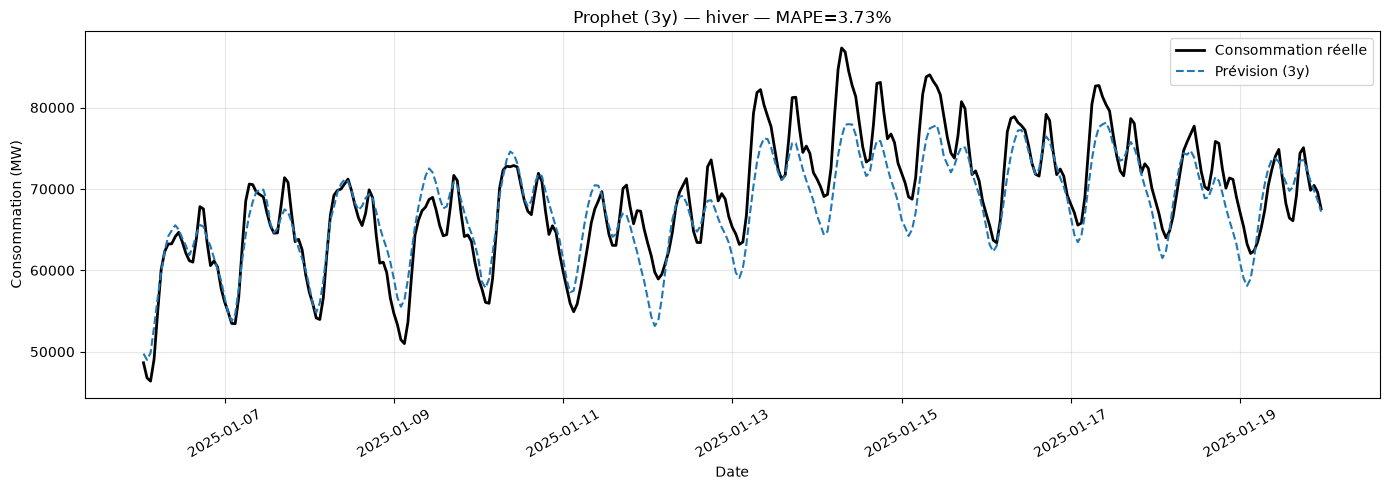

3y - été:   0%|          | 0/14 [00:00<?, ?it/s]Importing plotly failed. Interactive plots will not work.
Importing plotly failed. Interactive plots will not work.
Importing plotly failed. Interactive plots will not work.
Importing plotly failed. Interactive plots will not work.
Importing plotly failed. Interactive plots will not work.
Importing plotly failed. Interactive plots will not work.
Importing plotly failed. Interactive plots will not work.
Importing plotly failed. Interactive plots will not work.
Importing plotly failed. Interactive plots will not work.
Importing plotly failed. Interactive plots will not work.
07:51:44 - cmdstanpy - INFO - Chain [1] start processing
07:51:44 - cmdstanpy - INFO - Chain [1] start processing
07:51:44 - cmdstanpy - INFO - Chain [1] start processing
07:51:44 - cmdstanpy - INFO - Chain [1] start processing
07:51:44 - cmdstanpy - INFO - Chain [1] start processing
07:51:44 - cmdstanpy - INFO - Chain [1] start processing
07:51:44 - cmdstanpy - INFO - 

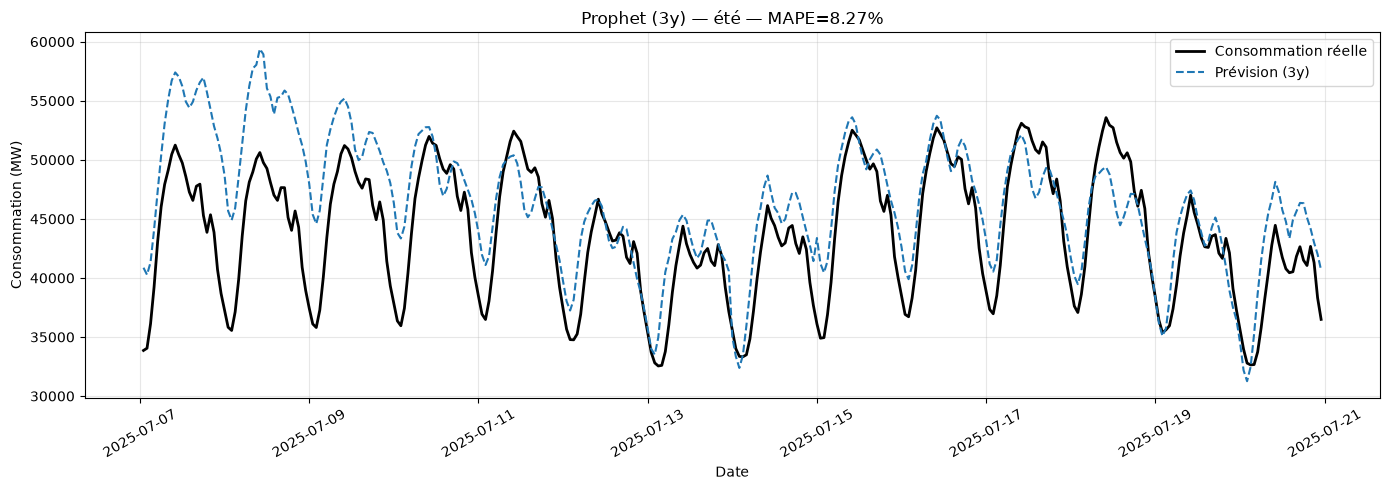

[3y] MAPE par fenêtre : {'hiver': 3.72701395415045, 'été': 8.272586584318294}
[3y] MAPE moyen : 6.00%


5.999800269234372

In [25]:
run_sliding_window_model("3y")


## 6bis. Modèle "1 an glissant"

Même principe que la section 6, avec `model_label = "1y"`. Cas limite pour `yearly_seasonality`
(un seul cycle annuel complet vu par le modèle, voir note en section 2) — à confronter aux
résultats une fois les deux modèles comparés.


1y - hiver:   0%|          | 0/14 [00:00<?, ?it/s]Importing plotly failed. Interactive plots will not work.
Importing plotly failed. Interactive plots will not work.
Importing plotly failed. Interactive plots will not work.
Importing plotly failed. Interactive plots will not work.
Importing plotly failed. Interactive plots will not work.
Importing plotly failed. Interactive plots will not work.
Importing plotly failed. Interactive plots will not work.
Importing plotly failed. Interactive plots will not work.
Importing plotly failed. Interactive plots will not work.
Importing plotly failed. Interactive plots will not work.
Importing plotly failed. Interactive plots will not work.
Importing plotly failed. Interactive plots will not work.
Importing plotly failed. Interactive plots will not work.
Importing plotly failed. Interactive plots will not work.
07:59:45 - cmdstanpy - INFO - Chain [1] start processing
07:59:45 - cmdstanpy - INFO - Chain [1] start processing
07:59:45 - cmdstanpy - I

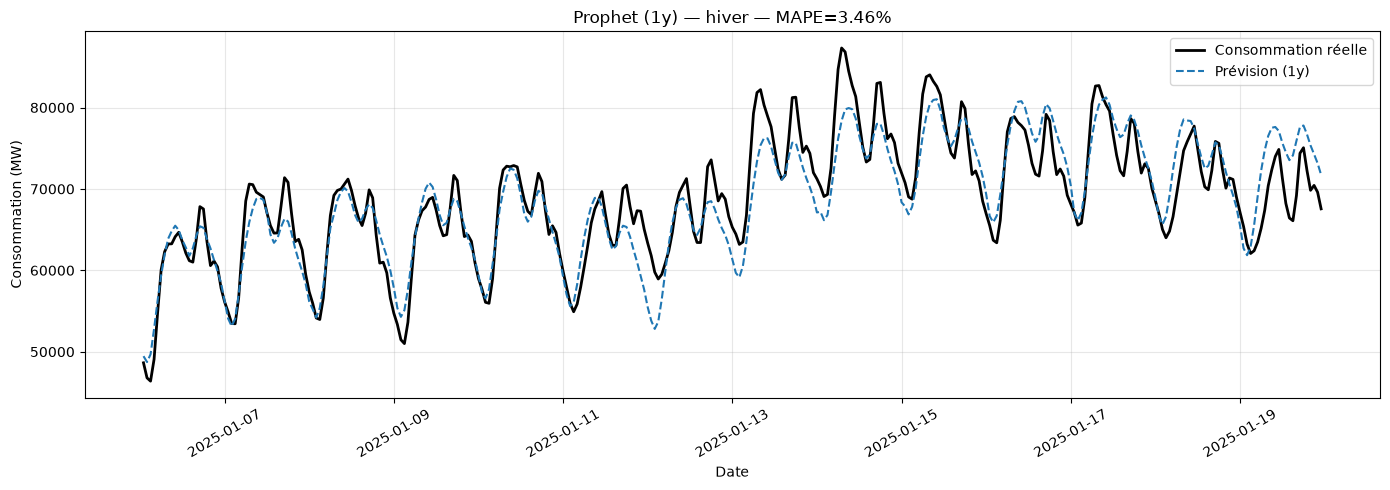

1y - été:   0%|          | 0/14 [00:00<?, ?it/s]Importing plotly failed. Interactive plots will not work.
Importing plotly failed. Interactive plots will not work.
Importing plotly failed. Interactive plots will not work.
Importing plotly failed. Interactive plots will not work.
Importing plotly failed. Interactive plots will not work.
Importing plotly failed. Interactive plots will not work.
Importing plotly failed. Interactive plots will not work.
Importing plotly failed. Interactive plots will not work.
08:00:03 - cmdstanpy - INFO - Chain [1] start processing
08:00:03 - cmdstanpy - INFO - Chain [1] start processing
Importing plotly failed. Interactive plots will not work.
Importing plotly failed. Interactive plots will not work.
08:00:03 - cmdstanpy - INFO - Chain [1] start processing
08:00:03 - cmdstanpy - INFO - Chain [1] start processing
08:00:03 - cmdstanpy - INFO - Chain [1] start processing
08:00:03 - cmdstanpy - INFO - Chain [1] start processing
08:00:03 - cmdstanpy - INFO - 

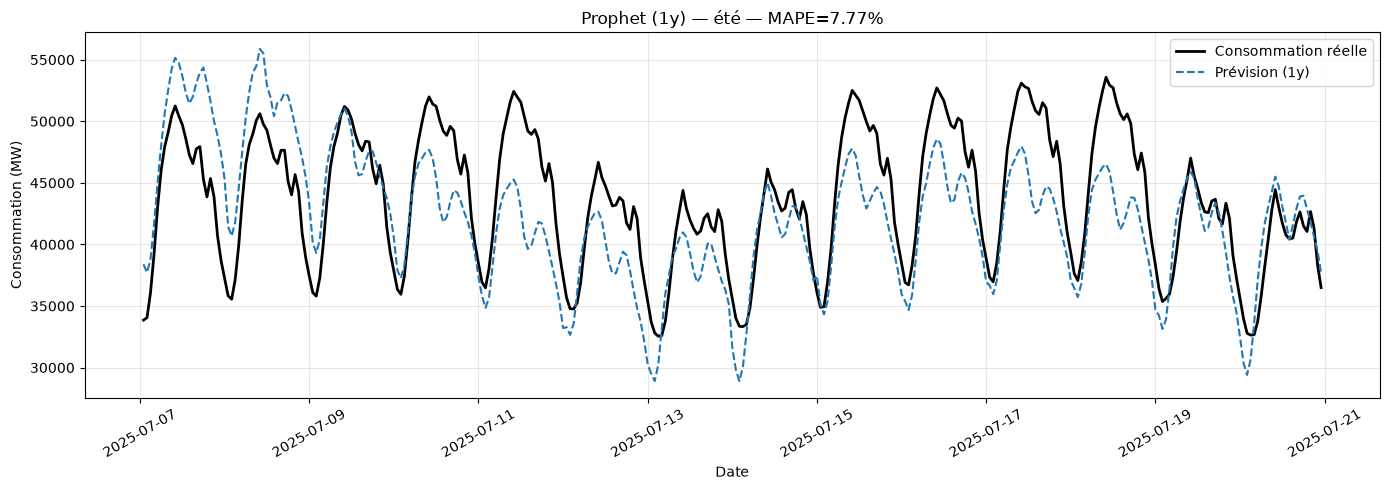

[1y] MAPE par fenêtre : {'hiver': 3.459068663728721, 'été': 7.774569467612665}
[1y] MAPE moyen : 5.62%


5.616819065670693

In [26]:
run_sliding_window_model("1y")


## 6ter. Modèle "26 semaines glissantes"


26w - hiver:   0%|          | 0/14 [00:00<?, ?it/s]08:00:44 - cmdstanpy - INFO - Chain [1] start processing
08:00:44 - cmdstanpy - INFO - Chain [1] start processing
08:00:44 - cmdstanpy - INFO - Chain [1] start processing
08:00:44 - cmdstanpy - INFO - Chain [1] start processing
08:00:44 - cmdstanpy - INFO - Chain [1] start processing
08:00:44 - cmdstanpy - INFO - Chain [1] start processing
08:00:44 - cmdstanpy - INFO - Chain [1] start processing
08:00:44 - cmdstanpy - INFO - Chain [1] start processing
08:00:44 - cmdstanpy - INFO - Chain [1] start processing
08:00:44 - cmdstanpy - INFO - Chain [1] start processing
08:00:44 - cmdstanpy - INFO - Chain [1] start processing
08:00:44 - cmdstanpy - INFO - Chain [1] start processing
08:00:44 - cmdstanpy - INFO - Chain [1] start processing
08:00:44 - cmdstanpy - INFO - Chain [1] start processing
08:00:44 - cmdstanpy - INFO - Chain [1] done processing
08:00:44 - cmdstanpy - INFO - Chain [1] done processing
08:00:44 - cmdstanpy - INFO - Chain [1]

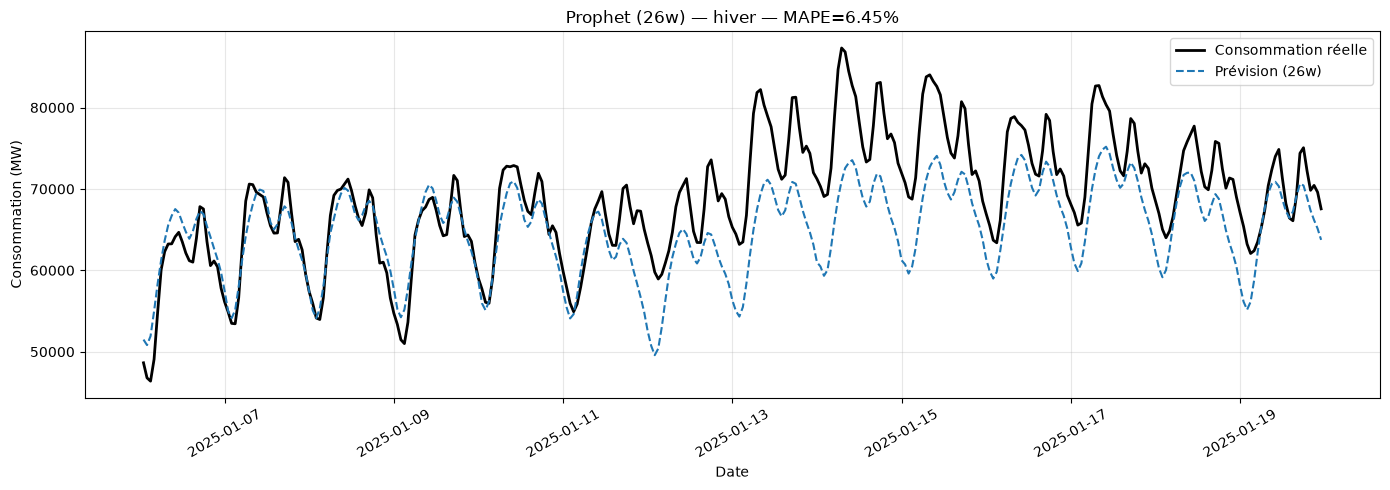

26w - été:   0%|          | 0/14 [00:00<?, ?it/s]08:00:45 - cmdstanpy - INFO - Chain [1] start processing
08:00:45 - cmdstanpy - INFO - Chain [1] start processing
08:00:45 - cmdstanpy - INFO - Chain [1] start processing
08:00:45 - cmdstanpy - INFO - Chain [1] start processing
08:00:45 - cmdstanpy - INFO - Chain [1] start processing
08:00:45 - cmdstanpy - INFO - Chain [1] start processing
08:00:45 - cmdstanpy - INFO - Chain [1] start processing
08:00:45 - cmdstanpy - INFO - Chain [1] start processing
08:00:45 - cmdstanpy - INFO - Chain [1] start processing
08:00:45 - cmdstanpy - INFO - Chain [1] start processing
08:00:45 - cmdstanpy - INFO - Chain [1] start processing
08:00:45 - cmdstanpy - INFO - Chain [1] start processing
08:00:45 - cmdstanpy - INFO - Chain [1] start processing
08:00:45 - cmdstanpy - INFO - Chain [1] start processing
08:00:46 - cmdstanpy - INFO - Chain [1] done processing
26w - été:   7%|▋         | 1/14 [00:01<00:14,  1.10s/it]08:00:47 - cmdstanpy - INFO - Chain [1] 

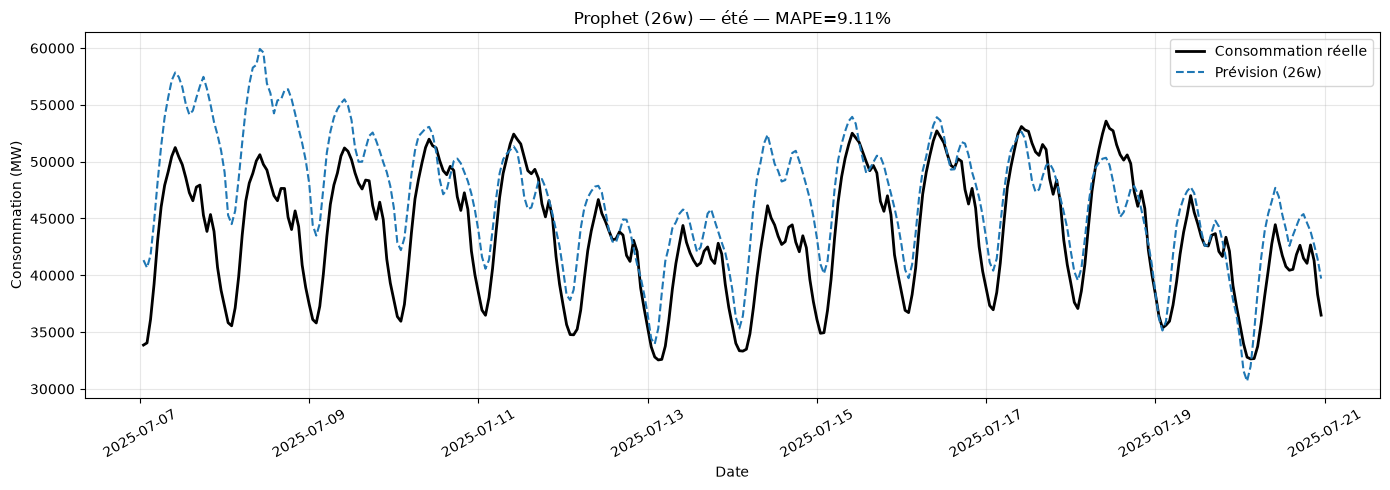

[26w] MAPE par fenêtre : {'hiver': 6.449209183731422, 'été': 9.112004998304291}
[26w] MAPE moyen : 7.78%


7.780607091017856

In [27]:
run_sliding_window_model("26w")


## 6quater. Modèle "12 semaines glissantes"


12w - hiver:   0%|          | 0/14 [00:00<?, ?it/s]08:01:11 - cmdstanpy - INFO - Chain [1] start processing
08:01:11 - cmdstanpy - INFO - Chain [1] start processing
08:01:11 - cmdstanpy - INFO - Chain [1] start processing
08:01:11 - cmdstanpy - INFO - Chain [1] start processing
08:01:11 - cmdstanpy - INFO - Chain [1] start processing
08:01:11 - cmdstanpy - INFO - Chain [1] start processing
08:01:11 - cmdstanpy - INFO - Chain [1] start processing
08:01:11 - cmdstanpy - INFO - Chain [1] start processing
08:01:11 - cmdstanpy - INFO - Chain [1] start processing
08:01:11 - cmdstanpy - INFO - Chain [1] start processing
08:01:11 - cmdstanpy - INFO - Chain [1] start processing
08:01:11 - cmdstanpy - INFO - Chain [1] start processing
08:01:11 - cmdstanpy - INFO - Chain [1] start processing
08:01:11 - cmdstanpy - INFO - Chain [1] start processing
08:01:11 - cmdstanpy - INFO - Chain [1] done processing
08:01:11 - cmdstanpy - INFO - Chain [1] done processing
12w - hiver:   7%|▋         | 1/14 [00:

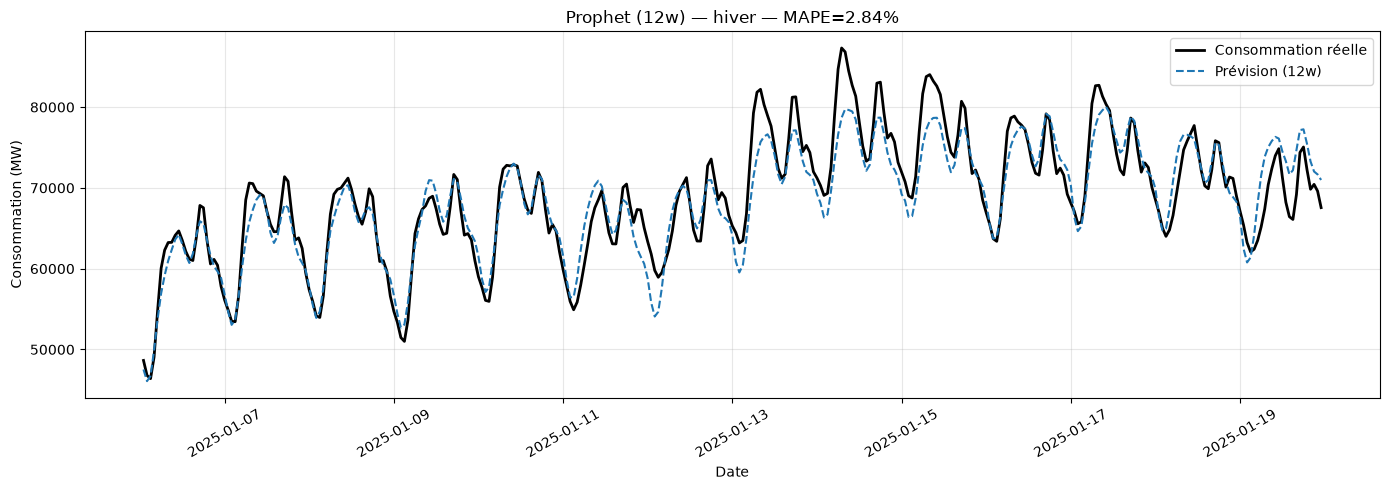

12w - été:   0%|          | 0/14 [00:00<?, ?it/s]08:01:11 - cmdstanpy - INFO - Chain [1] start processing
08:01:11 - cmdstanpy - INFO - Chain [1] start processing
08:01:11 - cmdstanpy - INFO - Chain [1] start processing
08:01:12 - cmdstanpy - INFO - Chain [1] start processing
08:01:12 - cmdstanpy - INFO - Chain [1] start processing
08:01:12 - cmdstanpy - INFO - Chain [1] start processing
08:01:12 - cmdstanpy - INFO - Chain [1] start processing
08:01:12 - cmdstanpy - INFO - Chain [1] start processing
08:01:12 - cmdstanpy - INFO - Chain [1] start processing
08:01:12 - cmdstanpy - INFO - Chain [1] start processing
08:01:12 - cmdstanpy - INFO - Chain [1] start processing
08:01:12 - cmdstanpy - INFO - Chain [1] start processing
08:01:12 - cmdstanpy - INFO - Chain [1] start processing
08:01:12 - cmdstanpy - INFO - Chain [1] start processing
08:01:12 - cmdstanpy - INFO - Chain [1] done processing
12w - été:   7%|▋         | 1/14 [00:00<00:04,  2.81it/s]08:01:12 - cmdstanpy - INFO - Chain [1] 

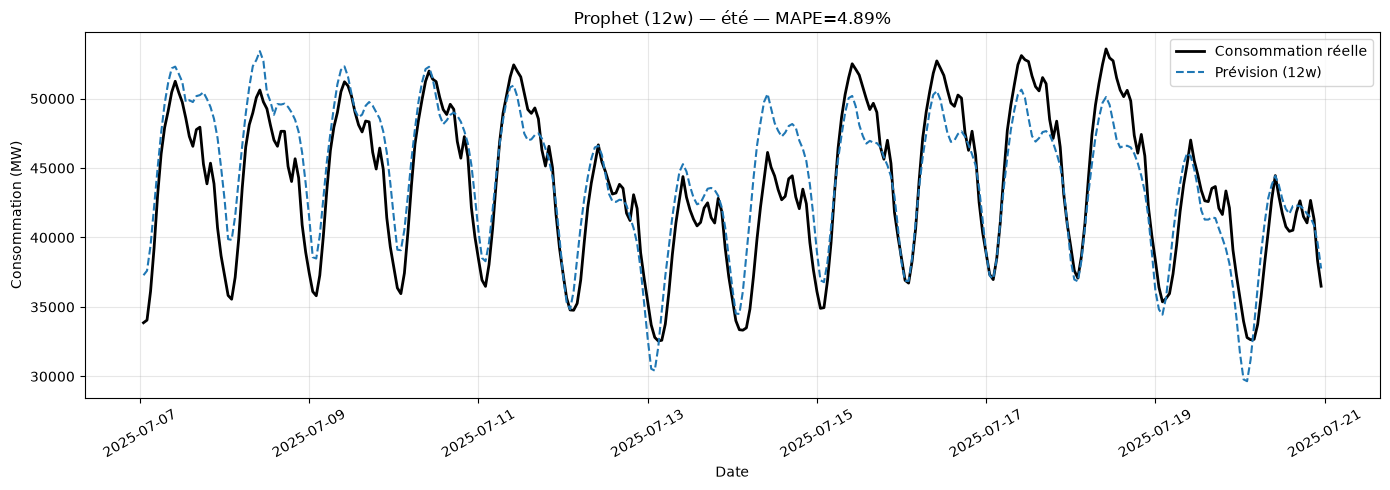

[12w] MAPE par fenêtre : {'hiver': 2.836310764955266, 'été': 4.8870858547648215}
[12w] MAPE moyen : 3.86%


3.861698309860044

In [28]:
run_sliding_window_model("12w")


## 6quinquies. Modèle "4 semaines glissantes"


4w - hiver:   0%|          | 0/14 [00:00<?, ?it/s]08:01:32 - cmdstanpy - INFO - Chain [1] start processing
08:01:32 - cmdstanpy - INFO - Chain [1] start processing
08:01:32 - cmdstanpy - INFO - Chain [1] start processing
08:01:32 - cmdstanpy - INFO - Chain [1] start processing
08:01:32 - cmdstanpy - INFO - Chain [1] start processing
08:01:32 - cmdstanpy - INFO - Chain [1] start processing
08:01:32 - cmdstanpy - INFO - Chain [1] start processing
08:01:32 - cmdstanpy - INFO - Chain [1] start processing
08:01:32 - cmdstanpy - INFO - Chain [1] start processing
08:01:32 - cmdstanpy - INFO - Chain [1] start processing
08:01:32 - cmdstanpy - INFO - Chain [1] start processing
08:01:32 - cmdstanpy - INFO - Chain [1] start processing
08:01:32 - cmdstanpy - INFO - Chain [1] start processing
08:01:32 - cmdstanpy - INFO - Chain [1] start processing
08:01:32 - cmdstanpy - INFO - Chain [1] done processing
08:01:32 - cmdstanpy - INFO - Chain [1] done processing
08:01:32 - cmdstanpy - INFO - Chain [1] 

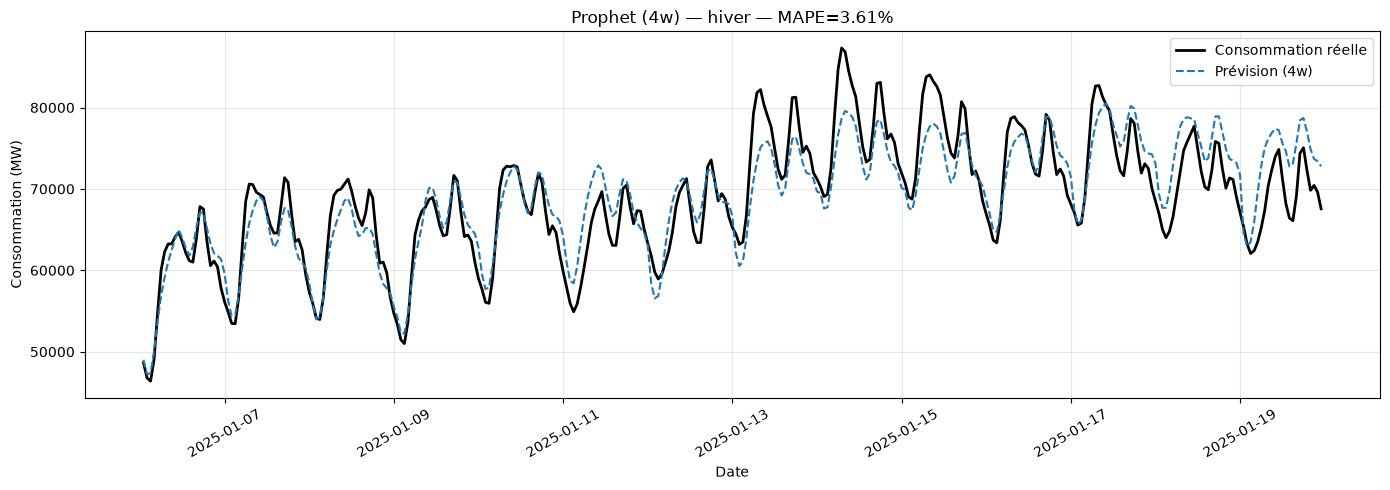

4w - été:   0%|          | 0/14 [00:00<?, ?it/s]08:01:32 - cmdstanpy - INFO - Chain [1] start processing
08:01:32 - cmdstanpy - INFO - Chain [1] start processing
08:01:32 - cmdstanpy - INFO - Chain [1] start processing
08:01:32 - cmdstanpy - INFO - Chain [1] start processing
08:01:32 - cmdstanpy - INFO - Chain [1] start processing
08:01:32 - cmdstanpy - INFO - Chain [1] start processing
08:01:32 - cmdstanpy - INFO - Chain [1] done processing
08:01:32 - cmdstanpy - INFO - Chain [1] start processing
08:01:32 - cmdstanpy - INFO - Chain [1] start processing
08:01:32 - cmdstanpy - INFO - Chain [1] start processing
08:01:33 - cmdstanpy - INFO - Chain [1] start processing
08:01:33 - cmdstanpy - INFO - Chain [1] start processing
08:01:33 - cmdstanpy - INFO - Chain [1] done processing
08:01:33 - cmdstanpy - INFO - Chain [1] start processing
08:01:33 - cmdstanpy - INFO - Chain [1] start processing
08:01:33 - cmdstanpy - INFO - Chain [1] done processing
08:01:33 - cmdstanpy - INFO - Chain [1] don

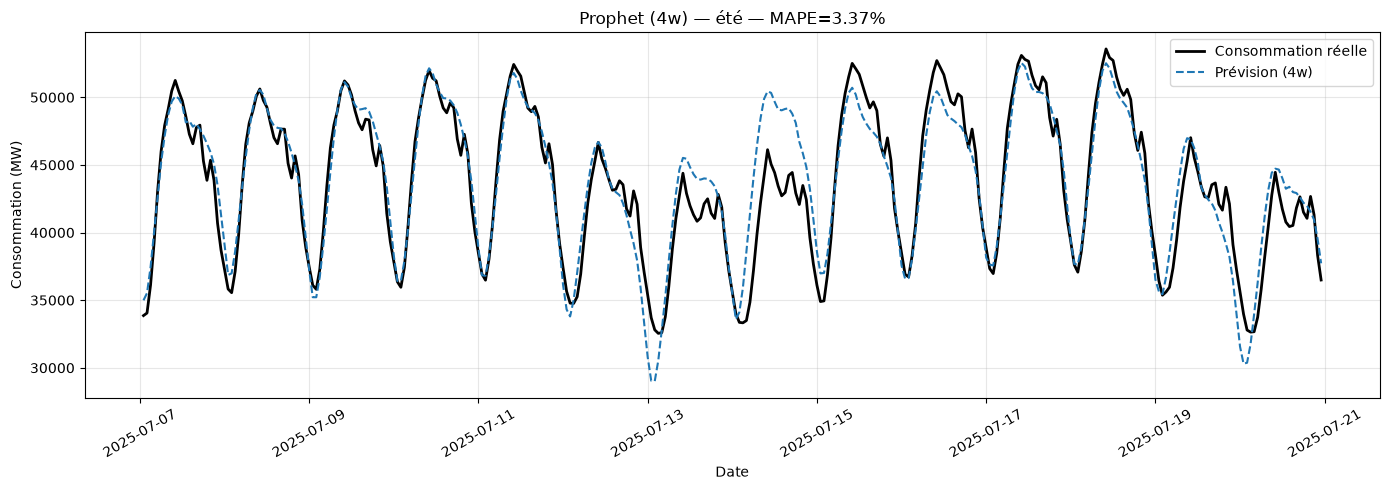

[4w] MAPE par fenêtre : {'hiver': 3.610382540937966, 'été': 3.3673946515301125}
[4w] MAPE moyen : 3.49%


3.4888885962340392

In [29]:
run_sliding_window_model("4w")


## 6sexies. Modèle "4 semaines glissantes" (saisonnalité hebdo weekday/weekend)

Variante de la section 6quinquies : même fenêtre glissante (4 semaines), mais la saisonnalité
hebdomadaire standard de Prophet (`weekly_seasonality=True`, une seule courbe moyenne sur 7 jours)
est remplacée par 2 saisonnalités hebdomadaires **conditionnelles** (`weekly_weekday` /
`weekly_weekend`, `fourier_order=3` chacune) — Prophet apprend alors des profils intra-semaine
différents pour les jours ouvrés et le week-end, plutôt qu'une seule courbe moyenne qui les mélange.


4w_split - hiver:   0%|          | 0/14 [00:00<?, ?it/s]Importing plotly failed. Interactive plots will not work.
Importing plotly failed. Interactive plots will not work.
Importing plotly failed. Interactive plots will not work.
Importing plotly failed. Interactive plots will not work.
Importing plotly failed. Interactive plots will not work.
Importing plotly failed. Interactive plots will not work.
Importing plotly failed. Interactive plots will not work.
Importing plotly failed. Interactive plots will not work.
Importing plotly failed. Interactive plots will not work.
Importing plotly failed. Interactive plots will not work.
Importing plotly failed. Interactive plots will not work.
Importing plotly failed. Interactive plots will not work.
Importing plotly failed. Interactive plots will not work.
Importing plotly failed. Interactive plots will not work.
08:13:36 - cmdstanpy - INFO - Chain [1] start processing
08:13:36 - cmdstanpy - INFO - Chain [1] start processing
08:13:36 - cmdstan

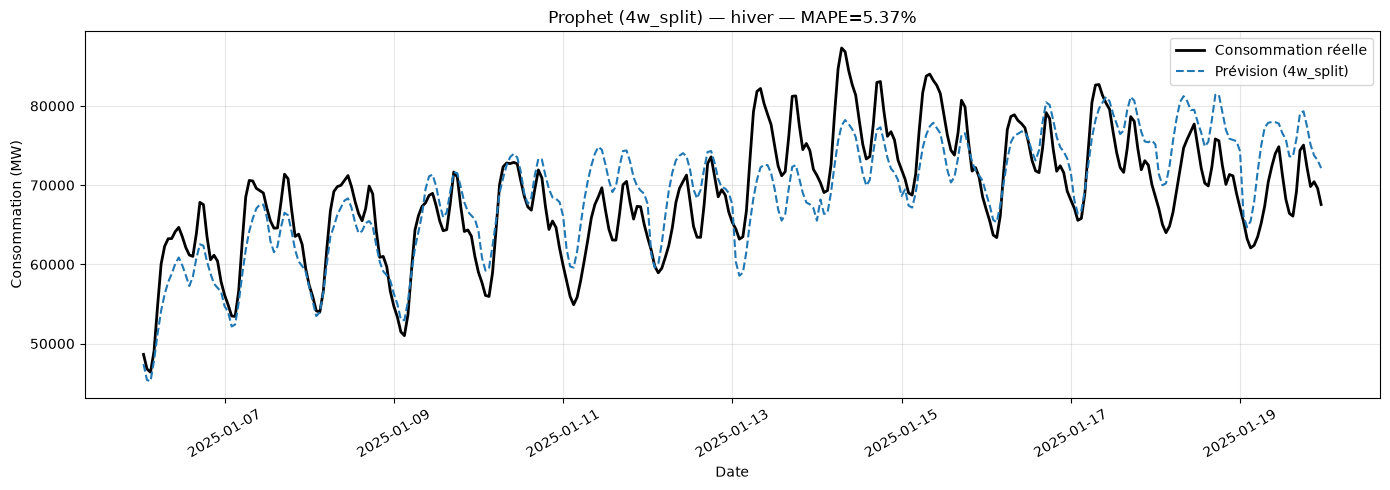

4w_split - été:   0%|          | 0/14 [00:00<?, ?it/s]08:13:36 - cmdstanpy - INFO - Chain [1] start processing
08:13:36 - cmdstanpy - INFO - Chain [1] start processing
08:13:36 - cmdstanpy - INFO - Chain [1] start processing
08:13:36 - cmdstanpy - INFO - Chain [1] start processing
08:13:36 - cmdstanpy - INFO - Chain [1] done processing
08:13:36 - cmdstanpy - INFO - Chain [1] done processing
08:13:36 - cmdstanpy - INFO - Chain [1] done processing
08:13:36 - cmdstanpy - INFO - Chain [1] done processing
4w_split - été:   7%|▋         | 1/14 [00:00<00:02,  4.71it/s]Importing plotly failed. Interactive plots will not work.
Importing plotly failed. Interactive plots will not work.
Importing plotly failed. Interactive plots will not work.
Importing plotly failed. Interactive plots will not work.
Importing plotly failed. Interactive plots will not work.
Importing plotly failed. Interactive plots will not work.
Importing plotly failed. Interactive plots will not work.
Importing plotly failed. I

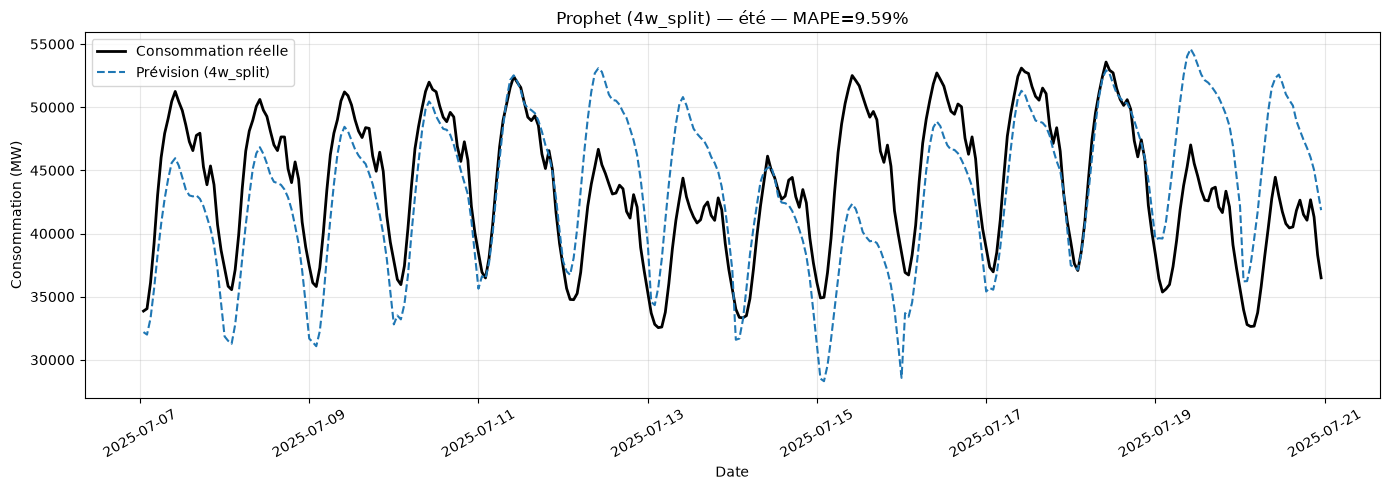

[4w_split] MAPE par fenêtre : {'hiver': 5.369221019337972, 'été': 9.591332226792138}
[4w_split] MAPE moyen : 7.48%


7.4802766230650555

In [32]:
run_sliding_window_model("4w_split")


## 7. Fine-tuning des hyperparamètres Prophet (modèles 4 semaines)

On se concentre sur les 2 variantes "4 semaines" (`"4w"` et `"4w_split"`) — la durée de fenêtre
utilisée en production (`RTE_predictions/ml/prophet/model_prophet.py`, 30 jours glissants) — et on
recherche en grille sur `changepoint_prior_scale` (flexibilité de la tendance), `seasonality_prior_scale`
(force des saisonnalités) et `seasonality_mode` (additive/multiplicative), autour des valeurs déjà
validées en production (`changepoint_prior_scale=0.35`, `seasonality_prior_scale=0.5`) et des
défauts Prophet (`0.05`/`10.0`) — grilles définies dans `CHANGEPOINT_PRIOR_SCALES` /
`SEASONALITY_PRIOR_SCALES` / `SEASONALITY_MODES` (section 2), ajustables librement.

`tune_4w_hyperparameters` réutilise `run_sliding_window_evaluation` telle quelle pour chaque
combinaison (même protocole que les sections 6.x : 2 fenêtres de test, cutoff quotidien) — les deux
variantes ("4w", "4w_split") sont tunées séparément, avec la même grille, pour pouvoir comparer leurs
meilleurs résultats respectifs une fois optimisées. Un seul run MLflow par variante résume tous les
essais (MAPE de chaque combinaison loggé en courbe via `step`, tableau complet en artifact CSV) —
pas un run par combinaison, pour ne pas encombrer l'expérience.


In [42]:
from itertools import product


def tune_4w_hyperparameters(base_model_label,
                             changepoint_prior_scales=None,
                             seasonality_prior_scales=None,
                             seasonality_modes=None):
    """Recherche en grille sur (changepoint_prior_scale x seasonality_prior_scale x
    seasonality_mode) pour la config de base `base_model_label` ("4w" ou "4w_split"). Pour chaque
    combinaison, réévalue le modèle sur les 2 fenêtres de test (hiver, été) via
    run_sliding_window_evaluation — même protocole que run_sliding_window_model, mais un seul run
    MLflow résume TOUS les essais (pas un run par combinaison). Retourne le tableau des essais,
    trié par MAPE moyen croissant (meilleur en premier).

    Les grilles par défaut (CHANGEPOINT_PRIOR_SCALES, etc., section 2) sont résolues ICI, dans le
    corps de la fonction, plutôt qu'en valeur par défaut du paramètre (`=CHANGEPOINT_PRIOR_SCALES`
    directement dans la signature) : une valeur par défaut est évaluée une seule fois, au moment où
    Python lit la définition `def ...`, pas à chaque appel. Si cette cellule tourne avant la
    cellule de configuration (section 2) — après un redémarrage du kernel, par exemple — cette
    résolution tardive évite un NameError."""
    changepoint_prior_scales = changepoint_prior_scales if changepoint_prior_scales is not None else CHANGEPOINT_PRIOR_SCALES
    seasonality_prior_scales = seasonality_prior_scales if seasonality_prior_scales is not None else SEASONALITY_PRIOR_SCALES
    seasonality_modes = seasonality_modes if seasonality_modes is not None else SEASONALITY_MODES

    mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)
    mlflow.set_experiment(EXPERIMENT_NAME)

    base_config = SLIDING_WINDOW_CONFIGS[base_model_label]
    combos = list(product(changepoint_prior_scales, seasonality_prior_scales, seasonality_modes))
    trials = []

    with mlflow.start_run(run_name=f"prophet_sliding_{base_model_label}_tuning"):
        mlflow.set_tags({
            "dataset_version": "2022_2025", "approach": "sliding_window", "stage": "hyperparameter_search",
        })
        mlflow.log_params({
            "base_model": base_model_label,
            "changepoint_prior_scales": str(changepoint_prior_scales),
            "seasonality_prior_scales": str(seasonality_prior_scales),
            "seasonality_modes": str(seasonality_modes),
            "n_combinations": len(combos),
        })

        for i, (cps, sps, mode) in enumerate(combos):
            trial_config = {
                **base_config,
                "changepoint_prior_scale": cps,
                "seasonality_prior_scale": sps,
                "seasonality_mode": mode,
            }

            mapes = {}
            for window_label, (window_start, window_end) in PLOT_WINDOWS.items():
                result_df = run_sliding_window_evaluation(
                    window_start, window_end, trial_config["train_window"], trial_config,
                    desc=f"{base_model_label} #{i + 1}/{len(combos)} cp={cps} sp={sps} {mode} - {window_label}",
                )
                mapes[window_label] = mean_absolute_percentage_error(result_df["y"], result_df["yhat"]) * 100

            mape_overall = sum(mapes.values()) / len(mapes)
            trials.append({
                "changepoint_prior_scale": cps,
                "seasonality_prior_scale": sps,
                "seasonality_mode": mode,
                "mape_hiver": mapes["hiver"],
                "mape_ete": mapes["été"],
                "mape_overall": mape_overall,
            })
            mlflow.log_metric("trial_mape_overall", mape_overall, step=i)

        trials_df = pd.DataFrame(trials).sort_values("mape_overall").reset_index(drop=True)
        best = trials_df.iloc[0].to_dict()

        mlflow.log_params({
            "best_changepoint_prior_scale": best["changepoint_prior_scale"],
            "best_seasonality_prior_scale": best["seasonality_prior_scale"],
            "best_seasonality_mode": best["seasonality_mode"],
        })
        mlflow.log_metric("best_mape_overall", best["mape_overall"])
        mlflow.log_text(trials_df.to_csv(index=False), "tuning_results.csv")

    print(f"[{base_model_label}] Meilleure combinaison : {best}")
    return trials_df


### 7.1. Tuning "4w" (saisonnalité hebdo standard)


In [43]:
trials_4w = tune_4w_hyperparameters("4w")
trials_4w.head(10)


4w #1/32 cp=0.05 sp=0.5 additive - hiver:   0%|          | 0/14 [00:00<?, ?it/s]Importing plotly failed. Interactive plots will not work.
Importing plotly failed. Interactive plots will not work.
Importing plotly failed. Interactive plots will not work.
Importing plotly failed. Interactive plots will not work.
Importing plotly failed. Interactive plots will not work.
Importing plotly failed. Interactive plots will not work.
Importing plotly failed. Interactive plots will not work.
Importing plotly failed. Interactive plots will not work.
Importing plotly failed. Interactive plots will not work.
Importing plotly failed. Interactive plots will not work.
Importing plotly failed. Interactive plots will not work.
Importing plotly failed. Interactive plots will not work.
Importing plotly failed. Interactive plots will not work.
Importing plotly failed. Interactive plots will not work.
08:37:52 - cmdstanpy - INFO - Chain [1] start processing
08:37:52 - cmdstanpy - INFO - Chain [1] start proce

[4w] Meilleure combinaison : {'changepoint_prior_scale': 0.35, 'seasonality_prior_scale': 5.0, 'seasonality_mode': 'additive', 'mape_hiver': 3.0037904161201783, 'mape_ete': 3.3265865169739453, 'mape_overall': 3.165188466547062}


,changepoint_prior_scale,seasonality_prior_scale,seasonality_mode,mape_hiver,mape_ete,mape_overall
0,0.35,5.0,additive,3.003790,3.326587,3.165188
1,0.35,0.5,additive,3.012287,3.321653,3.166970
2,0.35,10.0,additive,3.015986,3.339575,3.177781
3,0.35,1.0,additive,3.010484,3.348997,3.179741
4,0.20,10.0,additive,3.189866,3.309378,3.249622
5,0.20,1.0,additive,3.205322,3.305583,3.255452
6,0.20,0.5,additive,3.208693,3.306252,3.257472
7,0.20,5.0,additive,3.215990,3.301289,3.258639
8,0.20,0.5,multiplicative,3.186676,3.351167,3.268921
9,0.20,1.0,multiplicative,3.201445,3.352783,3.277114


### 7.2. Tuning "4w_split" (saisonnalité hebdo weekday/weekend)


In [44]:
trials_4w_split = tune_4w_hyperparameters("4w_split")
trials_4w_split.head(10)


4w_split #1/32 cp=0.05 sp=0.5 additive - hiver:   0%|          | 0/14 [00:00<?, ?it/s]08:38:36 - cmdstanpy - INFO - Chain [1] start processing
08:38:36 - cmdstanpy - INFO - Chain [1] start processing
08:38:36 - cmdstanpy - INFO - Chain [1] start processing
08:38:36 - cmdstanpy - INFO - Chain [1] start processing
08:38:36 - cmdstanpy - INFO - Chain [1] start processing
08:38:36 - cmdstanpy - INFO - Chain [1] start processing
08:38:36 - cmdstanpy - INFO - Chain [1] start processing
08:38:36 - cmdstanpy - INFO - Chain [1] start processing
08:38:36 - cmdstanpy - INFO - Chain [1] start processing
08:38:36 - cmdstanpy - INFO - Chain [1] start processing
08:38:36 - cmdstanpy - INFO - Chain [1] start processing
08:38:36 - cmdstanpy - INFO - Chain [1] start processing
08:38:36 - cmdstanpy - INFO - Chain [1] start processing
08:38:36 - cmdstanpy - INFO - Chain [1] start processing
08:38:36 - cmdstanpy - INFO - Chain [1] done processing
08:38:36 - cmdstanpy - INFO - Chain [1] done processing
08:3

[4w_split] Meilleure combinaison : {'changepoint_prior_scale': 0.35, 'seasonality_prior_scale': 1.0, 'seasonality_mode': 'multiplicative', 'mape_hiver': 2.506150166745714, 'mape_ete': 2.5351747659356736, 'mape_overall': 2.520662466340694}


,changepoint_prior_scale,seasonality_prior_scale,seasonality_mode,mape_hiver,mape_ete,mape_overall
0,0.35,1.0,multiplicative,2.506150,2.535175,2.520662
1,0.35,10.0,multiplicative,2.507181,2.544480,2.525831
2,0.35,5.0,multiplicative,2.527097,2.554968,2.541033
3,0.35,0.5,multiplicative,2.522099,2.565849,2.543974
4,0.35,10.0,additive,2.573382,2.591901,2.582641
5,0.50,5.0,additive,2.590210,2.577058,2.583634
6,0.20,5.0,multiplicative,2.592410,2.577606,2.585008
7,0.50,0.5,multiplicative,2.548924,2.625735,2.587330
8,0.20,10.0,multiplicative,2.592298,2.589207,2.590752
9,0.50,1.0,multiplicative,2.519199,2.664242,2.591721


## 8. Meilleur modèle "4w_split" fine-tuné — évaluation finale

Applique la meilleure combinaison d'hyperparamètres trouvée en section 7.2 (`trials_4w_split`,
déjà triée par MAPE croissant — `.iloc[0]` est donc le meilleur essai) à une évaluation complète et
"officielle" du modèle : construit une config `"4w_split_tuned"` (la config `"4w_split"` de base,
avec les 3 hyperparamètres tunés surchargés), puis appelle `run_sliding_window_model` dessus, comme
pour n'importe quel autre modèle — mêmes 2 graphes prévisions vs réel, même run MLflow dédié
(`prophet_sliding_4w_split_tuned`), pour comparaison directe avec les autres modèles de
l'expérience. Aucune fonction existante modifiée : on ne fait que réutiliser `run_sliding_window_model`
sur une config construite dynamiquement à partir du résultat du tuning.

**Dépend de `trials_4w_split`** (section 7.2) déjà calculé dans le kernel — relancer 7.2 d'abord si
besoin.


Meilleure config 4w_split (issue du tuning, section 7.2) :
{'train_window': <DateOffset: weeks=4>, 'yearly_seasonality': False, 'weekly_seasonality': False, 'daily_seasonality': True, 'weekly_seasonality_split': True, 'changepoint_prior_scale': np.float64(0.35), 'seasonality_prior_scale': np.float64(1.0), 'seasonality_mode': 'multiplicative'}


4w_split_tuned - hiver:   0%|          | 0/14 [00:00<?, ?it/s]Importing plotly failed. Interactive plots will not work.
Importing plotly failed. Interactive plots will not work.
Importing plotly failed. Interactive plots will not work.
Importing plotly failed. Interactive plots will not work.
Importing plotly failed. Interactive plots will not work.
Importing plotly failed. Interactive plots will not work.
Importing plotly failed. Interactive plots will not work.
Importing plotly failed. Interactive plots will not work.
Importing plotly failed. Interactive plots will not work.
Importing plotly failed. Interactive plots will not work.
Importing plotly failed. Interactive plots will not work.
Importing plotly failed. Interactive plots will not work.
Importing plotly failed. Interactive plots will not work.
Importing plotly failed. Interactive plots will not work.
08:47:32 - cmdstanpy - INFO - Chain [1] start processing
08:47:32 - cmdstanpy - INFO - Chain [1] start processing
08:47:32 - c

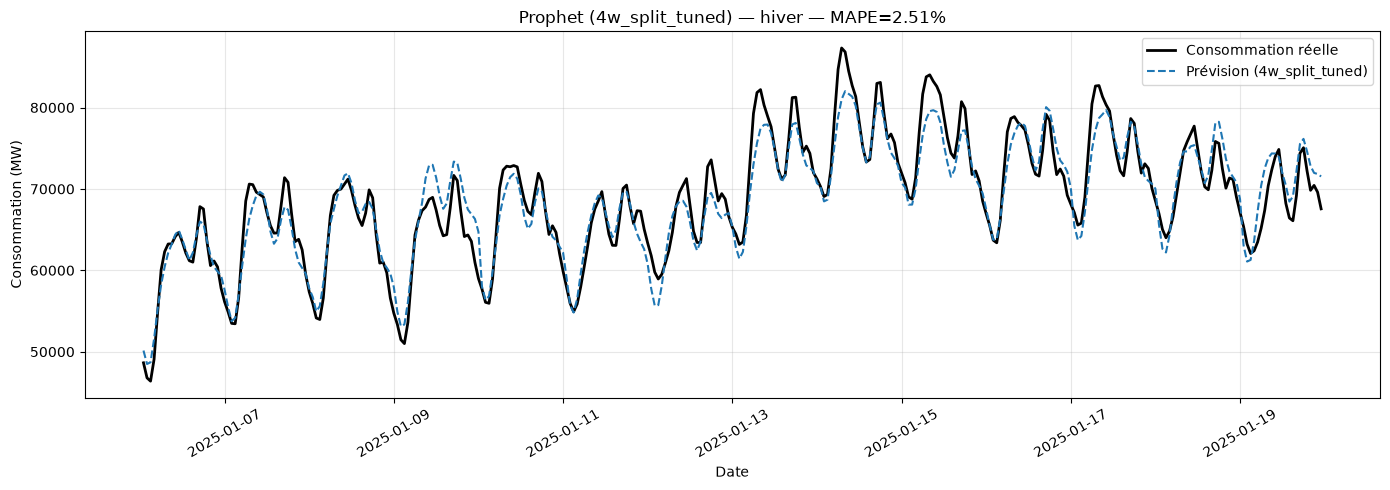

4w_split_tuned - été:   0%|          | 0/14 [00:00<?, ?it/s]08:47:33 - cmdstanpy - INFO - Chain [1] start processing
08:47:33 - cmdstanpy - INFO - Chain [1] start processing
08:47:33 - cmdstanpy - INFO - Chain [1] start processing
08:47:33 - cmdstanpy - INFO - Chain [1] start processing
08:47:33 - cmdstanpy - INFO - Chain [1] done processing
08:47:33 - cmdstanpy - INFO - Chain [1] done processing
4w_split_tuned - été:   7%|▋         | 1/14 [00:00<00:04,  3.15it/s]08:47:33 - cmdstanpy - INFO - Chain [1] done processing
08:47:33 - cmdstanpy - INFO - Chain [1] done processing
Importing plotly failed. Interactive plots will not work.
Importing plotly failed. Interactive plots will not work.
Importing plotly failed. Interactive plots will not work.
Importing plotly failed. Interactive plots will not work.
Importing plotly failed. Interactive plots will not work.
Importing plotly failed. Interactive plots will not work.
Importing plotly failed. Interactive plots will not work.
Importing plot

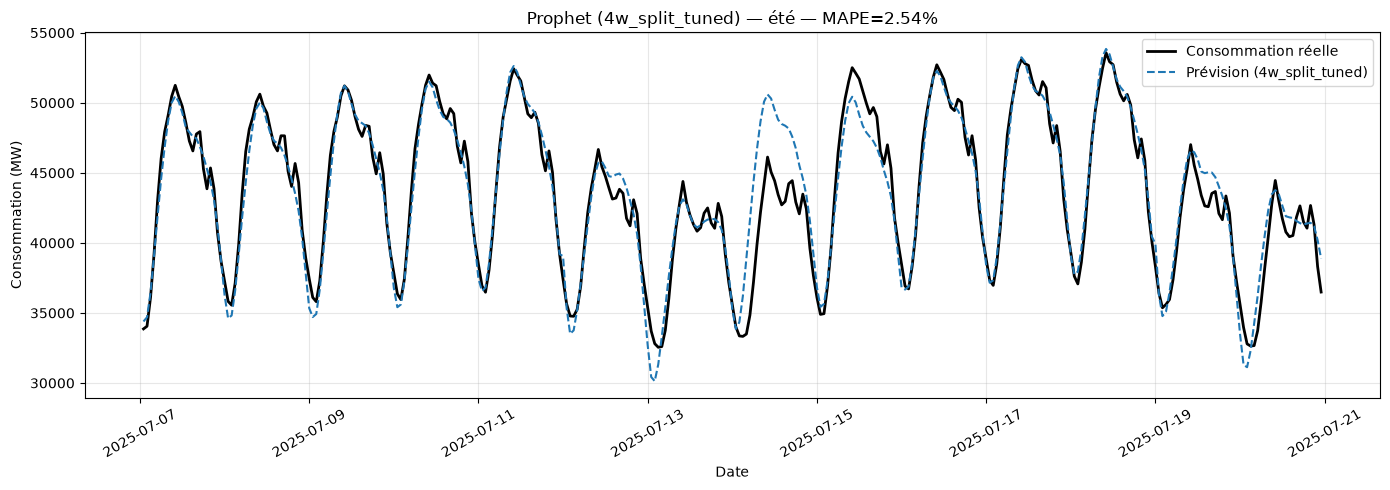

[4w_split_tuned] MAPE par fenêtre : {'hiver': 2.506150166745714, 'été': 2.5351747659356736}
[4w_split_tuned] MAPE moyen : 2.52%


2.520662466340694

In [45]:
best_4w_split = trials_4w_split.iloc[0]

SLIDING_WINDOW_CONFIGS["4w_split_tuned"] = {
    **SLIDING_WINDOW_CONFIGS["4w_split"],
    "changepoint_prior_scale": best_4w_split["changepoint_prior_scale"],
    "seasonality_prior_scale": best_4w_split["seasonality_prior_scale"],
    "seasonality_mode": best_4w_split["seasonality_mode"],
}

print("Meilleure config 4w_split (issue du tuning, section 7.2) :")
print(SLIDING_WINDOW_CONFIGS["4w_split_tuned"])

run_sliding_window_model("4w_split_tuned")
